In [4]:
import pandas as pd
data=pd.read_csv("/content/customer_churn_dataset-training-master.csv")
df=pd.DataFrame(data)
df.head()
df.shape
df.dtypes
df.select_dtypes(include="number").columns.tolist()
df.select_dtypes(include=["object","category"]).columns.tolist()
df.isnull()
df.isnull().sum()
target_cols = ["CustomerID", "Age",  "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",  "Total Spend", "Last Interaction", "Churn"]

df[target_cols] = df[target_cols].fillna(df[target_cols].mean(numeric_only=True))
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102828 entries, 0 to 102827
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         102828 non-null  int64  
 1   Age                102828 non-null  int64  
 2   Gender             102828 non-null  object 
 3   Tenure             102828 non-null  int64  
 4   Usage Frequency    102828 non-null  int64  
 5   Support Calls      102828 non-null  int64  
 6   Payment Delay      102828 non-null  int64  
 7   Subscription Type  102828 non-null  object 
 8   Contract Length    102827 non-null  object 
 9   Total Spend        102828 non-null  float64
 10  Last Interaction   102828 non-null  float64
 11  Churn              102828 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 9.4+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,102828.000000,102828.000000,102828.000000,102828.000000,102828.000000,102828.000000,102828.000000,102828.000000,102828.000000
mean,52482.585414,41.625880,30.475182,15.467431,5.099292,15.148714,544.565503,15.555778,0.987085
std,30678.457932,13.936397,17.346764,8.681367,3.151872,8.968660,259.617256,8.647132,0.112907
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,25715.750000,29.000000,15.000000,8.000000,2.000000,7.000000,320.000000,8.000000,1.000000
50%,52271.500000,42.000000,30.000000,15.000000,5.000000,15.000000,541.000000,16.000000,1.000000
75%,79064.250000,54.000000,45.000000,23.000000,8.000000,23.000000,769.000000,23.000000,1.000000
max,105922.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [5]:
df.isnull()
df.isnull().sum()

df["Contract Length"].unique()
df["Subscription Type"].unique()
df["Gender"].unique()

categorical_columns=["Gender","Subscription Type","Contract Length"]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode())


df.duplicated()
df.duplicated().sum()
df.drop_duplicates().shape[0]

for col in categorical_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip() # Strip spaces
print(df.info())

df["CustomerID"]=df["CustomerID"].astype(int)







<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102828 entries, 0 to 102827
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         102828 non-null  int64  
 1   Age                102828 non-null  int64  
 2   Gender             102828 non-null  object 
 3   Tenure             102828 non-null  int64  
 4   Usage Frequency    102828 non-null  int64  
 5   Support Calls      102828 non-null  int64  
 6   Payment Delay      102828 non-null  int64  
 7   Subscription Type  102828 non-null  object 
 8   Contract Length    102828 non-null  object 
 9   Total Spend        102828 non-null  float64
 10  Last Interaction   102828 non-null  float64
 11  Churn              102828 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 9.4+ MB
None


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percentages)


df['Churn'] = df['Churn'].round().astype(int)


display(df['Churn'].value_counts())
display(df['Churn'].value_counts(normalize=True) * 100)

categorical_features = ['Gender', 'Subscription Type', 'Contract Length']

for feature in categorical_features:

    print(df[feature].value_counts())
    print(df[feature].value_counts(normalize=True) * 100)


Churn
1.000000    237931
0.000000      3634
0.984956         2
Name: count, dtype: int64
Churn
1.000000    98.494828
0.000000     1.504345
0.984956     0.000828
Name: proportion, dtype: float64


,count
Churn,
1,237933
0,3634


,proportion
Churn,
1,98.495655
0,1.504345



--- Gender ---
Gender
Female    122177
Male      119389
nan            1
Name: count, dtype: int64
Gender
Female    50.576859
Male      49.422727
nan        0.000414
Name: proportion, dtype: float64

--- Subscription Type ---
Subscription Type
Standard    80781
Premium     80443
Basic       80341
nan             2
Name: count, dtype: int64
Subscription Type
Standard    33.440412
Premium     33.300492
Basic       33.258268
nan          0.000828
Name: proportion, dtype: float64

--- Contract Length ---
Contract Length
Monthly      82916
Annual       79556
Quarterly    79093
nan              2
Name: count, dtype: int64
Contract Length
Monthly      34.324225
Annual       32.933306
Quarterly    32.741641
nan           0.000828
Name: proportion, dtype: float64


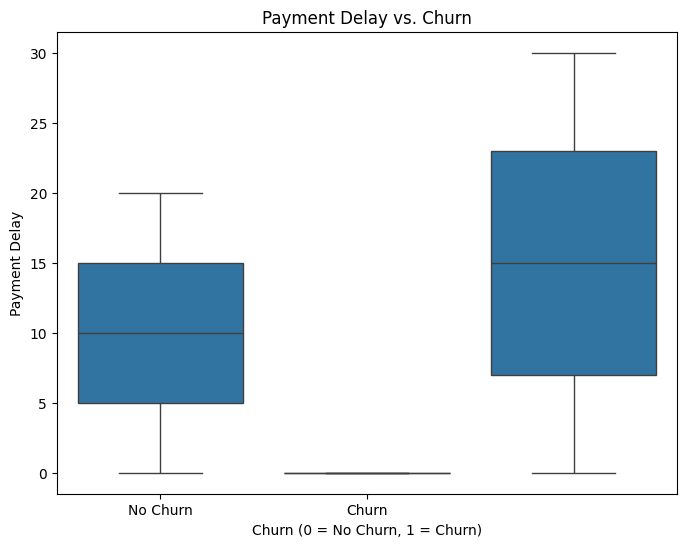

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Payment Delay', data=df)
plt.title('Payment Delay vs. Churn')
plt.xlabel('Churn (0 = No Churn, 1 = Churn)')
plt.ylabel('Payment Delay')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()